lokale csv 02Apple_Offline.csv wird geladen...
1 01.01.2019 0.533772
2 01.02.2019 0.506205
3 01.03.2019 0.479701
4 01.04.2019 0.43889
5 01.05.2019 0.398695
6 01.06.2019 0.482466
7 01.07.2019 0.414841
8 01.08.2019 0.401148
9 01.09.2019 0.404933
10 01.10.2019 0.370875
11 01.11.2019 0.325599
12 01.12.2019 0.314376
13 01.01.2020 0.276496
14 01.02.2020 0.269052
15 01.03.2020 0.277263
16 01.04.2020 0.3439
17 01.05.2020 0.286605
18 01.06.2020 0.256719
19 01.07.2020 0.226924
20 01.08.2020 0.189616
21 01.09.2020 0.153668
22 01.10.2020 0.176549
23 01.11.2020 0.189566
24 01.12.2020 0.167728
25 01.01.2021 0.159057
26 01.02.2021 0.153449
27 01.03.2021 0.160833
28 01.04.2021 0.167097
29 01.05.2021 0.155069
30 01.06.2021 0.165095
31 01.07.2021 0.149472
32 01.08.2021 0.140998
33 01.09.2021 0.134334
34 01.10.2021 0.14362


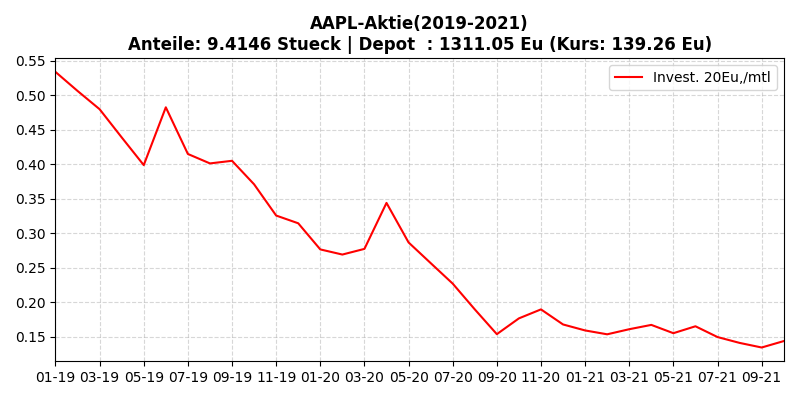

In [1]:
# AAPL_Beispiel.py  Übungsbeispiel 50Zeilen Aktiensparen zwischen 2019 und 2021
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import os
%matplotlib widget
csv_Nam ="02Apple_Offline.csv"  # geht von 2015 bis 2026,boersentaeglich!
if os.path.exists(csv_Nam):
   print(f"lokale csv {csv_Nam} wird geladen...")
   df_csv = pd.read_csv(csv_Nam)
   df_csv['Date'] = pd.to_datetime(df_csv['Date'])
   df = df_csv.sort_values('Date').reset_index(drop=True)
   df.set_index('Date', inplace=True) 
df_aktiensparen = df.loc['2019-01-01':'2021-10-01'].copy()
df_monthly = df_aktiensparen.resample("MS").first()
df_monthly = df_monthly.dropna(subset=["Price"])
investment_per_month = 20
raten_plan = []
raten_nr = 0
for date, row in df_monthly.iterrows():
    price = row["Price"]
    units = investment_per_month / price
    datum = date.strftime("%d.%m.%Y")
    rate  = round(units,6)
    raten_nr = raten_nr + 1
    print(raten_nr,datum,rate)
    raten_plan.append(rate)
# depot-wert
gesamte_anteile = sum(raten_plan)
letzter_preis = df_monthly["Price"].iloc[-1]
depot_wert = gesamte_anteile * letzter_preis
# x-werte entspr. monatlich
x_zahlen = np.arange(len(df_monthly))
y = raten_plan
x_labels = [date.strftime("%m-%y") for date in df_monthly.index]
plt.figure(figsize=(8, 4))
plt.plot(x_zahlen, y, label='Invest. 20Eu‚/mtl' 
                    , color='red', linestyle='solid') 
# x-Achse enstspr Anzahl der Werte
plt.xlim(0, len(df_monthly) - 1)
# Anzeige jeder zweite Monat
plt.xticks(ticks=x_zahlen[::2], labels=x_labels[::2], rotation=0)
titel_text = (f"AAPL-Aktie(2019-2021)\n"
              f"Anteile: {gesamte_anteile:.4f} Stueck | "
              f"Depot  : {depot_wert:.2f} Eu (Kurs: {letzter_preis:.2f} Eu)")
plt.title(titel_text, fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
